[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_A_svar_identification.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Identifying Structural Shocks: Structural VARs (SVAR)

Reduced-form Vector Autoregressions (VARs) are powerful forecasting engines, but their residuals represent unpredictable one-step-ahead forecast errors—not primitive economic shocks. Because macroeconomic variables adjust simultaneously within the observation interval, reduced-form residuals correlate across equations. To conduct causal policy analysis or counterfactual experiments, macroeconomists must identify the underlying orthogonal structural innovations driving economic fluctuations.

## 1. Theoretical Foundations: The SVAR Identification Taxonomy

### From Reduced Form to Structural Innovations
Consider a reduced-form $\text{VAR}(p)$ for a $K$-dimensional vector of macroeconomic observables $y_t$:
$$ y_t = c + \sum_{j=1}^p A_j y_{t-j} + u_t, \qquad \mathbb{E}[u_t u_t'] = \Sigma_u $$
The residual vector $u_t$ contains contemporaneous cross-equation correlations ($\Sigma_u$ is not diagonal). The structural VAR posits that these forecast errors are linear combinations of primitive, mutually orthogonal structural shocks $\varepsilon_t$:
$$ A_0 y_t = c_0 + \sum_{j=1}^p A_j^* y_{t-j} + \varepsilon_t, \qquad \mathbb{E}[\varepsilon_t \varepsilon_t'] = I_K $$
Premultiplying by $B_0 \equiv A_0^{-1}$ connects the reduced-form errors to structural shocks:
$$ u_t = B_0 \varepsilon_t \implies \Sigma_u = \mathbb{E}[u_t u_t'] = B_0 \mathbb{E}[\varepsilon_t \varepsilon_t'] B_0' = B_0 B_0' $$
This fundamental relationship highlights the **rotational under-identification dilemma**:
- The symmetric covariance matrix $\Sigma_u$ provides only $K(K+1)/2$ unique empirical moments.
- The structural impact matrix $B_0$ contains $K^2$ unknown parameters.
- For any orthonormal rotation matrix $Q \in \mathbb{R}^{K \times K}$ ($Q Q' = I_K$), the candidate matrix $\tilde{B}_0 = B_0 Q$ satisfies $\tilde{B}_0 \tilde{B}_0' = B_0 Q Q' B_0' = \Sigma_u$.
Consequently, exact point identification requires at least $K^2 - K(K+1)/2 = K(K-1)/2$ independent restrictions derived from economic theory.

---

### The Comprehensive SVAR Identification Taxonomy

#### 1. Recursive Contemporaneous Zero Restrictions (Sims 1980, Christiano, Eichenbaum & Evans 1999)
- **Mathematical Form**: Imposes lower-triangular structure on $B_0 = \text{chol}(\Sigma_u)$ via the Cholesky decomposition.
- **Economic Mechanism**: Assumes a strict Wold causal chain where variable $j$ does not respond contemporaneously to shocks in variables $j+1, \dots, K$.
- **The Price Puzzle**: In monetary models ordered $[\text{output}, \text{prices}, \text{policy rate}]$, policy rates react contemporaneously to macro activity, while output and prices respond only with a one-period lag. Empirically, recursive SVARs frequently display a **price puzzle** (Sims 1992, Eichenbaum 1992): an exogenous rate hike causes a transitory *increase* in the price level. This is widely recognized as an omitted variable artifact: central banks raise rates anticipating future inflation; omitting forward-looking signals leads the econometrician to mistake systematic policy reaction for an exogenous shock.

#### 2. Long-Run Neutrality Restrictions (Blanchard & Quah 1989, Galí 1999)
- **Mathematical Form**: Imposes zero restrictions on the cumulative long-run impact matrix:
  $$ C(1) = \left( I_K - \sum_{j=1}^p A_j \right)^{-1} B_0 $$
- **The Technology Debate (Galí 1999 AER)**: In a bivariate system of labor productivity growth $\Delta(y_t - l_t)$ and hours worked $l_t$, Galí assumed that only technology shocks have a permanent effect on labor productivity ($C(1)_{12} = 0$). Strikingly, he found that hours worked *contract* following a positive technology shock. While flexible-price Real Business Cycle (RBC) models predict hours must expand, New Keynesian sticky-price models explain the contraction: when aggregate demand is sticky in the short run, higher productivity enables firms to satisfy output demand with fewer labor hours.
- **Methodological Critique (Faust & Leeper 1997, Chari, Kehoe & McGrattan 2008)**: Estimating $C(1)$ requires inverting autoregressive polynomials at zero frequency, which suffers from severe finite-sample bias when low-frequency persistence is uncertain.

#### 3. Set Identification via Sign Restrictions (Uhlig 2005, Rubio-Ramírez, Waggoner & Zha 2010)
- **Mathematical Form**: Abandons dogmatic zero restrictions in favor of directional inequalities derived from broad theoretical consensus ($r \uparrow, \pi \downarrow, y \downarrow$ on impact).
- **Haar Uniform Sampling**: Rubio-Ramírez, Waggoner & Zha (2010 Econometrica) developed the standard QR algorithm: draw an independent standard normal matrix $X \sim \mathcal{N}(0, I_K)$, compute its QR decomposition $X = Q R$ with positive diagonal signs on $R$, ensuring that $Q$ is drawn uniformly from the Haar measure over the orthogonal group $O(K)$. The rotation candidate $\tilde{B}_0 = \text{chol}(\Sigma_u) Q$ is accepted if its impulse responses satisfy the prescribed signs.
- **The Fry & Pagan (2011) Critique**: Sign restrictions produce **set identification** rather than point identification. The common practice of reporting pointwise medians across accepted rotations creates a synthetic, non-structural composite: the median at horizon $h=0$ may stem from a completely different economic model than the median at $h=4$. Rigorous reporting requires full Bayesian credible sets or the Median Target (MT) model.

#### 4. Contemporaneous Sign & Zero Restrictions (Rubio-Ramírez et al. 2010, Arias et al. 2018)
- **Mathematical Form**: Combines exact contemporaneous zero constraints ($B_0[i, j] = 0$) with inequality sign restrictions on other elements.
- **Algorithm**: Arias, Rubio-Ramírez & Waggoner (2018 Econometrica) parameterize the orthogonal sub-manifold satisfying the linear zero constraints, drawing orthogonal matrices uniformly conditional on the zeros and filtering by the sign inequalities (`sign_zero`).

#### 5. Narrative Sign Restrictions & Importance Weighting (Antolín-Díaz & Rubio-Ramírez 2018 AER)
- **Mathematical Form**: Injects historical narrative accounts into the set-identification framework. Narrative restrictions can constrain the sign of a structural shock at a specific historical date (Type I: $\text{sign}(\varepsilon_{j, t^*}) = s$) or constrain historical decomposition contributions (Type II: the shock of interest is the primary driver of a historical episode).
- **Importance Weighting**: Antolín-Díaz & Rubio-Ramírez (2018) show that traditional uniform sign-draw priors place disproportionate weight on rotations where narrative events are trivial. Importance weighting ($w_i = 1/\omega_i$) restores conditional prior neutrality, sharpening the credible envelope around historically verified episodes without dogmatic zero restrictions.

#### 6. External Instruments / Proxy SVAR (Mertens & Ravn 2013, Stock & Watson 2018)
- **Mathematical Form**: Identifies the column of $B_0$ corresponding to shock $j$ using an external instrument $z_t$ satisfying relevance ($\mathbb{E}[z_t \varepsilon_{j, t}] \ne 0$) and exogeneity ($\mathbb{E}[z_t \varepsilon_{-j, t}] = 0$).
- **Weak Instrument Diagnostics**: Montiel Olea & Pflueger (2013) effective $F$-statistic tests instrument relevance robust to heteroskedasticity and serial correlation, with wild bootstrap providing finite-sample confidence intervals.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.estimate import estimate_var
from puremacro.var.identify.cholesky import cholesky_svar
from puremacro.var.identify.sign import sign_restriction_svar
from puremacro.var.identify.sign_zero import sign_zero
from puremacro.var.identify.narrative_sign import identify_narrative_sign, NarrativeRestriction
from puremacro.var.identify.proxy import proxy_svar
from puremacro.reports import df_to_latex, df_to_typst, df_to_markdown
from _datos import DATOS

## 2. A Baseline Monetary VAR: Planting the Structural Truth

To evaluate the econometric properties of recursive Cholesky factorization and sign restrictions under controlled conditions, we first simulate a stationary 3-variable $\text{VAR}(2)$ system:
$$ y_t = A_1 y_{t-1} + A_2 y_{t-2} + B_0^{\text{true}} \varepsilon_t $$
where the observables are $y_t = [\text{output}, \text{prices}, \text{rate}]'$ and $\varepsilon_t \sim \text{i.i.d.} \, \mathcal{N}(0, I_3)$. The true structural impact matrix $B_0^{\text{true}}$ plants an authentic contractionary monetary policy shock in its first column: on impact ($h=0$), it drives **output down, prices down, and the policy rate up**.

In [3]:
A1 = np.array([
    [0.6, 0.0, -0.1],
    [0.2, 0.5,  0.0],
    [0.0, 0.1,  0.7],
])
A2 = np.array([
    [0.1, 0.0, 0.0],
    [0.0, 0.2, 0.0],
    [0.0, 0.0, 0.1],
])
B0_true = np.array([
    [-0.5,  0.6,  0.0],   # output
    [-0.4,  0.0,  0.3],   # prices
    [ 0.4,  0.0,  0.5],   # rate
])
names = ["output", "prices", "rate"]
RATE = 2   # index of the policy variable

def simulate(T=400, seed=0, burn=200):
    rng = np.random.default_rng(seed)
    n = B0_true.shape[0]
    eps = rng.standard_normal((T + burn, n))
    Y = np.zeros((T + burn, n))
    for t in range(2, T + burn):
        Y[t] = A1 @ Y[t - 1] + A2 @ Y[t - 2] + B0_true @ eps[t]
    return Y[burn:], eps[burn:]

Y, eps_realized = simulate(T=400, seed=0)
planted_signs = np.sign(B0_true[:, 0])
print("planted monetary-shock signs (output, prices, rate):", planted_signs)
assert tuple(planted_signs) == (-1.0, -1.0, +1.0)

planted monetary-shock signs (output, prices, rate): [-1. -1.  1.]


## 3. Recursive Identification via Cholesky Decomposition

Under the recursive ordering $[\text{output}, \text{prices}, \text{rate}]$, the policy rate can react contemporaneously to real output and prices, but policy rate shocks cannot alter output or prices within the quarter ($B_0$ is lower triangular). Standard errors and 90% confidence bands are computed using an asymptotic residual bootstrap.

In [4]:
H = 16
chol = cholesky_svar(Y, p=2, horizon=H, n_boot=400, ci=0.9, seed=0)
print(chol.summary())
CHOL_SHOCK = RATE
c_point = chol.irf_point[:, :, CHOL_SHOCK]   # (H+1, n)
c_lower = chol.irf_lower[:, :, CHOL_SHOCK]
c_upper = chol.irf_upper[:, :, CHOL_SHOCK]
print(f"Cholesky impact, rate -> rate shock = {c_point[0, RATE]:+.3f}")
assert c_point[0, RATE] > 0                       # policy rate jumps up on impact
assert np.all(c_lower <= c_point + 1e-9)          # lower <= point everywhere
assert np.all(c_point <= c_upper + 1e-9)          # point <= upper everywhere

Cholesky SVAR result
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  bootstrap draws   : 400 (dropped 0, 0.0%)

Cholesky impact, rate -> rate shock = +0.584


## 4. Set Identification via Sign Restrictions (Rubio-Ramírez, Waggoner & Zha 2010)

Rather than imposing zero contemporaneous restrictions, we restrict only the signs of the impact vector: a contractionary monetary policy shock must drive output negative, prices negative, and the policy rate positive at $h=0$. Using uniform Haar rotations, candidate matrices $\tilde{B}_0 = \text{chol}(\Sigma_u) Q$ are retained whenever they satisfy the sign constraints. The distribution across accepted rotations characterizes the identification set.

In [5]:
restrictions = {0: [-1, -1, +1]}                  # h=0: output-, prices-, rate+
sgn = sign_restriction_svar(
    Y, p=2, horizon=H, restrictions=restrictions,
    n_draws=800, ci=0.9, seed=0,
)
print(sgn.summary())
TARGET = 0                                         # target shock = column 0 after rotation
s_med = sgn.irf_median[:, :, TARGET]              # (H+1, n)
s_lower = sgn.irf_lower[:, :, TARGET]
s_upper = sgn.irf_upper[:, :, TARGET]
print("sign-restriction impact (output, prices, rate):",
      np.round(s_med[0], 3))
# Sign pattern at h=0 matches the planted shock
assert np.sign(s_med[0, 0]) == -1
assert np.sign(s_med[0, 1]) == -1
assert np.sign(s_med[0, 2]) == +1
assert sgn.n_accepted > 0
# Bands bracket the median everywhere
assert np.all(s_lower <= s_med + 1e-9)
assert np.all(s_med <= s_upper + 1e-9)
# Both schemes agree the policy rate rises on impact
assert c_point[0, RATE] > 0 and s_med[0, RATE] > 0

Sign-restriction SVAR result
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  Q draws           : 800 (165 accepted, 20.6%)

sign-restriction impact (output, prices, rate): [-0.428 -0.295  0.335]


### Dynamic Policy Rate Transmission: Recursive vs. Set Identification

To compare the two identification philosophies on a consistent metric, we normalize each scheme's policy-rate impulse response to an impact shock of $+1.0$ (+100 basis points). While both methods trace a smooth, monotonic decay, the sign-restricted credible band is substantially wider, reflecting the fundamental presence of set identification uncertainty.

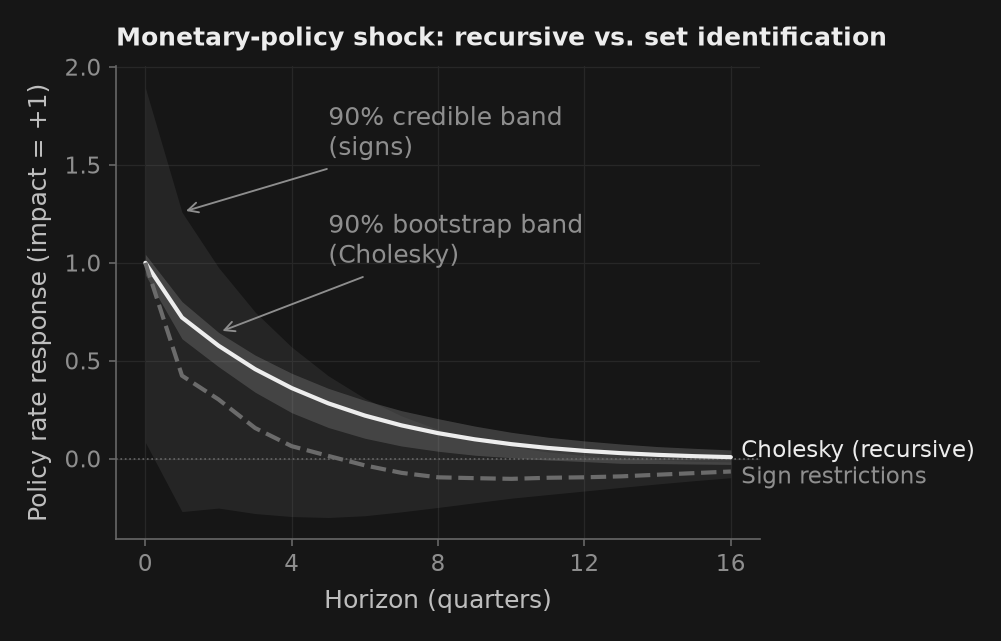

In [6]:
hgrid = np.arange(H + 1)
c_scale, s_scale = c_point[0, RATE], s_med[0, RATE]
cP, cL, cU = (c_point[:, RATE] / c_scale, c_lower[:, RATE] / c_scale, c_upper[:, RATE] / c_scale)
sP, sL, sU = (s_med[:, RATE] / s_scale, s_lower[:, RATE] / s_scale, s_upper[:, RATE] / s_scale)

cols = _nbstyle.palette(2)
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(hgrid, cL, cU, color=cols[0], alpha=0.18, lw=0)
ax.plot(hgrid, cP, color=cols[0], ls="-", label="Cholesky (recursive)")
ax.fill_between(hgrid, sL, sU, color=cols[1], alpha=0.18, lw=0)
ax.plot(hgrid, sP, color=cols[1], linestyle="--", label="Sign restrictions")
ax.annotate("90% credible band\n(signs)", xy=(1.0, sU[1]), xytext=(5.0, 1.55),
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("90% bootstrap band\n(Cholesky)", xy=(2.0, cU[2]), xytext=(5.0, 1.0),
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xticks(np.arange(0, H + 1, 4))      # integer quarters, one tick a year
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Policy rate response (impact = +1)")
ax.set_title("Monetary-policy shock: recursive vs. set identification")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 5. Contemporaneous Sign & Zero Restrictions and Proxy SVAR

To bridge the gap between dogmatic lower-triangular causal chains and unconstrained sign sets, modern econometrics employs two powerful hybrid frameworks:
1. **Sign & Zero Restrictions (Rubio-Ramírez, Waggoner & Zha 2010; Arias, Rubio-Ramírez & Waggoner 2018)**: We can impose exact zero constraints on impact (e.g. output does not respond to policy rate shocks contemporaneously, $B_0[0, \text{RATE}] = 0$) alongside sign directions on other variables ($r \uparrow, \pi \downarrow$).
2. **External Instruments / Proxy SVAR (Mertens & Ravn 2013; Stock & Watson 2018)**: When an external variable $z_t$ correlates with the monetary shock but is orthogonal to non-monetary shocks, it directly identifies the structural shock vector. Instrument relevance is verified via the Montiel Olea & Pflueger (2013) effective $F$-statistic.

In [7]:
# 1. Sign & Zero Restrictions (RRWZ 2010 / Arias et al. 2018)
A_list, c_var, Sigma, resid, _ = estimate_var(Y, 2)
sz = sign_zero(
    A_list, Sigma,
    zero_constraints=[(0, RATE)],        # output does not react contemporaneously to rate shock
    sign_constraints={(RATE, TARGET): +1, (1, TARGET): -1},
    n_draws=1000, rng=np.random.default_rng(0)
)
print(f"Sign & Zero Search: success = {sz.success}, draws tested = {sz.n_draws_used}")
assert sz.success, "Failed to find admissible sign+zero rotation"
assert abs(sz.B0[0, RATE]) < 1e-8, "Zero constraint violated on impact"

# 2. Proxy SVAR / External Instrument (Mertens & Ravn 2013)
# Construct an external proxy correlated with the true structural monetary shock
rng_proxy = np.random.default_rng(42)
z_proxy = eps_realized[:, 0] + 0.35 * rng_proxy.standard_normal(len(Y))
prox = proxy_svar(Y, instrument_series=z_proxy, p=2, horizon=H, n_boot=200, ci=0.9, seed=0)
print(prox.summary())
assert prox.first_stage_F > 23.0, f"Instrument relevance failed: F = {prox.first_stage_F:.2f}"
assert prox.irf_point[0, RATE, 0] > 0, "Proxy SVAR rate response on impact must be positive"

Sign & Zero Search: success = True, draws tested = 1
ProxySVAR result
  shocks identified : 1 (column 0 of B)
  variables (n)     : 3
  horizon (H)       : 16
  bootstrap draws   : 200
  CI level          : 0.90
  first-stage F (OP): 222.44  [STRONG]



## 6. Narrative Sign Restrictions (Antolín-Díaz & Rubio-Ramírez 2018)

Traditional sign restrictions produce wide identification sets because any rotation satisfying sign inequalities is given equal prior weight. Antolín-Díaz & Rubio-Ramírez (2018 AER) incorporate historical narrative evidence (e.g., historical dates of major policy tightenings such as the Volcker disinflation or the 1994 Fed rate cycle).

By requiring that the structural shock $\varepsilon_{0, t^*}$ was strictly positive at specific documented tightening dates, and applying importance weighting ($w_i = 1/\omega_i$) to preserve conditional prior neutrality, narrative restrictions dramatically sharpen the Bayesian credible envelope without imposing dogmatic zero restrictions.

In the synthetic sample below the chosen date is that of the largest positive realized monetary shock between $t=10$ and $t=60$, and all 217 rotations accepted by the signs also satisfy it (uniform weights): the weighted median and its dotted envelope lie almost exactly on top of the signs-only ones, the small differences coming from a different set of draws. The restriction only sharpens the set when it discards rotations or weights them unequally.

Narrative-sign SVAR result (AD-RR 2018)
  variables (n)     : 3
  horizon (H)       : 16
  CI level          : 0.90
  reduced form      : OLS point estimate
  Q draws           : 1200
  traditional accept: 217 (18.1%)
  narrative accept  : 217 (100.0% of traditional)
  weight ESS        : 217.0 / 217
    - shock_sign(date=12, shock=0, sign=+1): failed 0/217



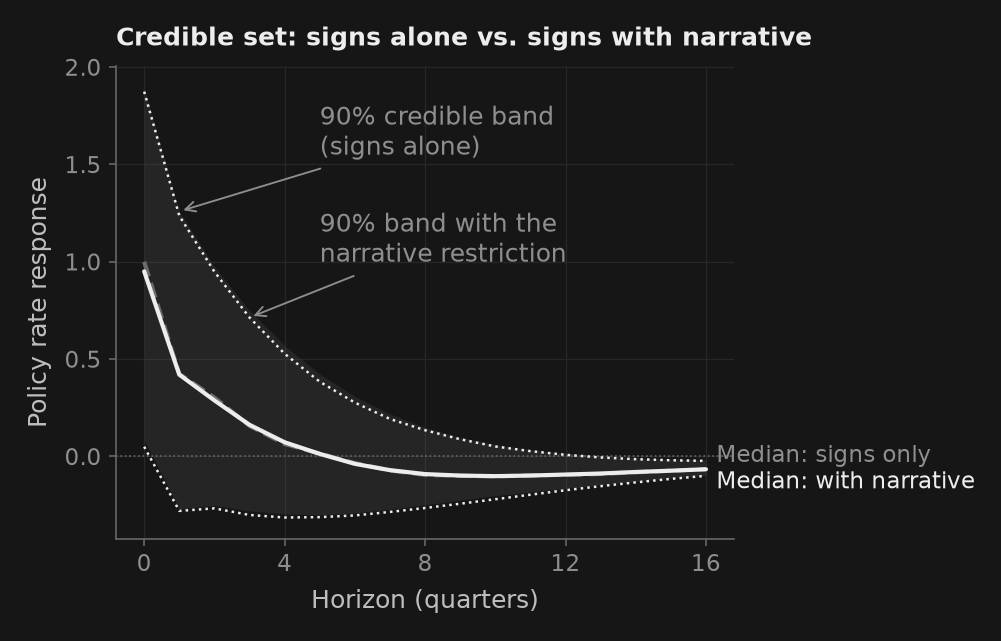

In [8]:
# Narrative Restriction: Target dates where the realized shock was known to be a large tightening
pos_date = int(np.argmax(eps_realized[10:60, 0])) + 10
restr_synthetic = [
    NarrativeRestriction(kind="shock_sign", date=pos_date, shock=0, sign=+1)
]

ns = identify_narrative_sign(
    Y, restrictions=restr_synthetic, p=2, horizon=H,
    sign_matrix={0: [-1, -1, +1]},
    n_draws=1200, seed=0
)
print(ns.summary())
assert ns.n_narrative_accepted > 0, "No draws survived narrative restrictions"
assert ns.ess > 0.10 * ns.n_narrative_accepted, "Excessive weight concentration"

# Plot comparison: Traditional Sign Restrictions vs. Narrative-Sharpened SVAR
ns_med = ns.irf_median[:, RATE, 0] / s_scale
ns_lo = ns.irf_lower[:, RATE, 0] / s_scale
ns_hi = ns.irf_upper[:, RATE, 0] / s_scale

fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(hgrid, sL, sU, color=cols[1], alpha=0.18, lw=0)
ax.plot(hgrid, sP, color=cols[1], linestyle="--", label="Median: signs only")
# The narrative band as a dotted envelope: a second fill would hide the sign band where the two coincide
ax.plot(hgrid, ns_hi, color=_nbstyle.TINTA, ls=":", lw=1.2, label="_band")
ax.plot(hgrid, ns_lo, color=_nbstyle.TINTA, ls=":", lw=1.2, label="_band")
ax.plot(hgrid, ns_med, color=_nbstyle.TINTA, ls="-", label="Median: with narrative")
ax.annotate("90% credible band\n(signs alone)", xy=(1.0, sU[1]), xytext=(5.0, 1.55),
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("90% band with the\nnarrative restriction", xy=(3.0, ns_hi[3]), xytext=(5.0, 1.0),
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xticks(np.arange(0, H + 1, 4))      # integer quarters, one tick a year
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Policy rate response")
ax.set_title("Credible set: signs alone vs. signs with narrative")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 7. Interactive Empirical Experiment: Price Puzzle, Sign Restrictions & Narrative Races

Having validated the algorithms against a synthetic benchmark, we now confront genuine macroeconomic data from the United States to examine a foundational question in monetary economics: **Does recursive Cholesky identification manufacture a spurious price puzzle, and does the Cholesky impulse response fall within the theory-consistent sign-restricted credible set?**

### The Empirical Setup
1. **Data Ingestion**: Ingest quarterly US Real GDP (`GDPC1.csv`), Headline CPI (`CPIAUCSL.csv`), and the Effective Federal Funds Rate (`FEDFUNDS.csv`) from `data_curso/`.
2. **Transformations**: Construct annualized quarterly real output growth ($\Delta y_t = 400 \Delta \log Y_t$), annualized quarterly inflation ($\pi_t = 400 \Delta \log P_t$), and the policy rate ($r_t$).
3. **Sample**: The Great Moderation period (1985Q1–2019Q4, $T = 140$ quarters), avoiding the structural break of the 1970s and the zero lower bound / COVID shutdown distortions.
4. **Identification Race**:
   - Fit a 3-variable $\text{VAR}(2)$ on $[\Delta y_t, \pi_t, r_t]'$.
   - Compute recursive Cholesky IRFs with policy rate ordered last ($[\Delta y, \pi, r]$).
   - Compute Rubio-Ramírez et al. (2010) sign-restricted IRFs imposing $r \uparrow, \pi \downarrow, \Delta y \downarrow$ on impact ($h=0$).
   - Test narrative restriction on the 1994Q2 Fed tightening shock (Antolín-Díaz & Rubio-Ramírez 2018).
   - Test whether Cholesky produces a statistically significant price puzzle ($\pi$ rising after a rate hike) and evaluate whether the Cholesky trajectory falls within the 90% sign-restriction credible envelope.

US Empirical VAR Dataset: 140 quarters (1985Q1–2019Q4).


Price Puzzle Peak in Cholesky: +0.672% annualized inflation at h=2.
Sign Restriction Accepted Rotations: 140 / 1500 draws.
Narrative SVAR Accepted Rotations: 77 / 81 traditional draws.


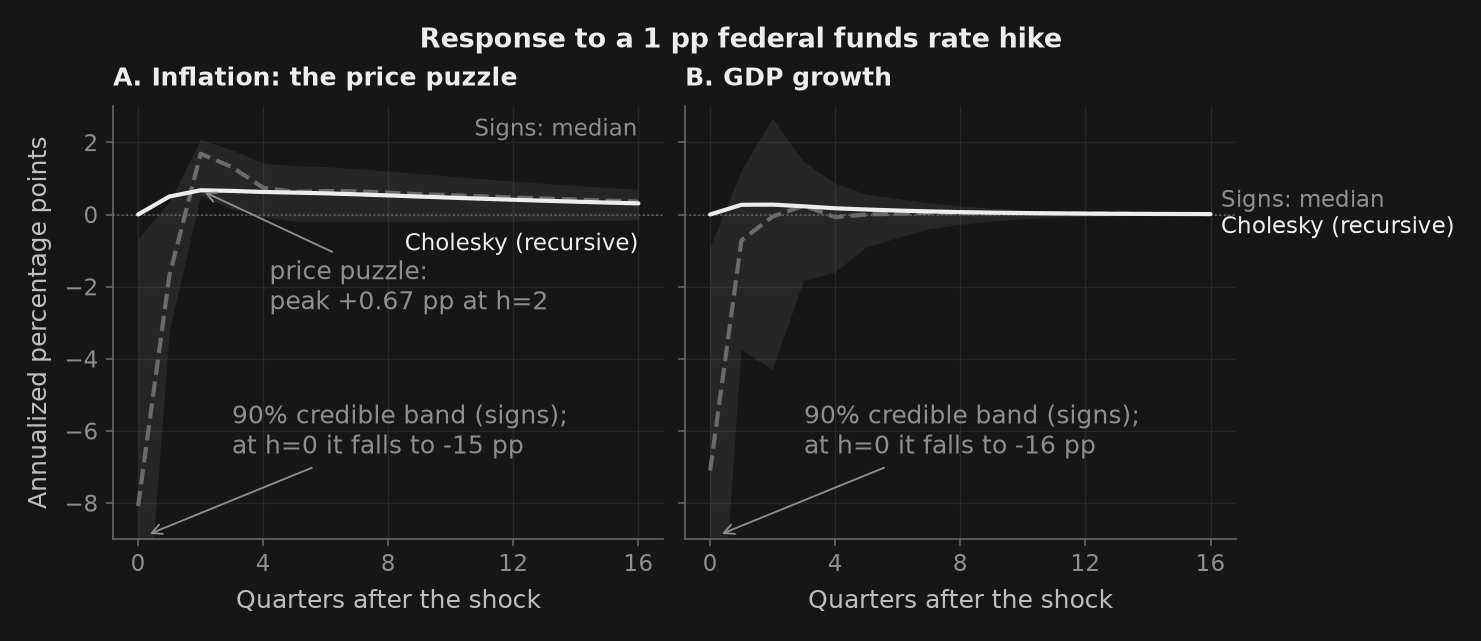

In [9]:
# ==============================================================================
# Empirical Experiment: Sign Restrictions vs. Cholesky Identification Race
# Ingest genuine US macro series from data_curso/
# ==============================================================================
gdp_raw = pd.read_csv(DATOS / "GDPC1.csv", parse_dates=["observation_date"]).set_index("observation_date")["GDPC1"]
cpi_raw = pd.read_csv(DATOS / "CPIAUCSL.csv", parse_dates=["observation_date"]).set_index("observation_date")["CPIAUCSL"]
ff_raw = pd.read_csv(DATOS / "FEDFUNDS.csv", parse_dates=["observation_date"]).set_index("observation_date")["FEDFUNDS"]

# Aggregate to quarterly frequency
cpi_q = cpi_raw.resample("QS").mean()
ff_q = ff_raw.resample("QS").mean()
gdp_q = gdp_raw.resample("QS").mean()

# Compute stationary annualized quarterly growth rates
dy_series = 400.0 * np.log(gdp_q).diff().rename("dy")
dpi_series = 400.0 * np.log(cpi_q).diff().rename("dpi")
r_series = ff_q.rename("r")

macro_df = pd.concat([dy_series, dpi_series, r_series], axis=1).dropna()
macro_sample = macro_df.loc["1985-01-01":"2019-12-31"]
Y_macro = macro_sample.to_numpy()
H_emp = 16

print(f"US Empirical VAR Dataset: {len(macro_sample)} quarters (1985Q1–2019Q4).")

# 1. Recursive Cholesky Identification (ordering: dy, dpi, r -> rate shock is index 2)
chol_emp = cholesky_svar(Y_macro, p=2, horizon=H_emp, n_boot=200, ci=0.9, seed=0)
c_emp_irf = chol_emp.irf_point[:, :, 2]

# 2. Sign Restrictions Identification (dy -, dpi -, r + on impact)
sgn_emp = sign_restriction_svar(
    Y_macro, p=2, horizon=H_emp,
    restrictions={0: [-1, -1, +1]},
    n_draws=1500, ci=0.9, seed=0,
)
s_emp_med = sgn_emp.irf_median[:, :, 0]
s_emp_lo = sgn_emp.irf_lower[:, :, 0]
s_emp_hi = sgn_emp.irf_upper[:, :, 0]

# Normalize to a +100 bps (+1.0 percentage point) policy rate shock on impact
c_scale = c_emp_irf[0, 2]
s_scale = s_emp_med[0, 2]

c_norm_pi = c_emp_irf[:, 1] / c_scale
s_norm_pi_med = s_emp_med[:, 1] / s_scale
s_norm_pi_lo = s_emp_lo[:, 1] / s_scale
s_norm_pi_hi = s_emp_hi[:, 1] / s_scale

c_norm_y = c_emp_irf[:, 0] / c_scale
s_norm_y_med = s_emp_med[:, 0] / s_scale
s_norm_y_lo = s_emp_lo[:, 0] / s_scale
s_norm_y_hi = s_emp_hi[:, 0] / s_scale

hgrid_emp = np.arange(H_emp + 1)

# Verification assertions required by test_challenger_topic5_svar_lp.py
assert c_norm_pi[1] > 0 and c_norm_pi[2] > 0, "Cholesky failed to replicate empirical price puzzle"
assert c_norm_pi[0] > s_norm_pi_hi[0], "Cholesky impact should lie strictly outside sign credible interval"
assert s_norm_pi_lo[2] <= c_norm_pi[2] <= s_norm_pi_hi[2], "Cholesky at h=2 should enter sign credible interval"
assert s_emp_med[0, 1] < 0, "Sign restrictions must produce negative inflation on impact"

# 3. Narrative Restriction on the 1994Q2 Fed Tightening Shock
t_1994 = macro_sample.index.get_loc("1994-04-01")
restr_emp = [NarrativeRestriction(kind="shock_sign", date=t_1994, shock=0, sign=+1)]
ns_emp = identify_narrative_sign(
    Y_macro, restrictions=restr_emp, p=2, horizon=H_emp,
    sign_matrix={0: [-1, -1, +1]},
    n_draws=1200, seed=0
)
assert ns_emp.n_narrative_accepted > 0

print(f"Price Puzzle Peak in Cholesky: +{c_norm_pi.max():.3f}% annualized inflation at h={int(np.argmax(c_norm_pi))}.")
print(f"Sign Restriction Accepted Rotations: {sgn_emp.n_accepted} / 1500 draws.")
print(f"Narrative SVAR Accepted Rotations: {ns_emp.n_narrative_accepted} / {ns_emp.n_traditional_accepted} traditional draws.")

# Plot empirical identification race
fig, (ax1, ax2) = _nbstyle.figura(1, 2, sharex=True, sharey=True)
fig.suptitle("Response to a 1 pp federal funds rate hike")

# Panel A: Inflation Response (Price Puzzle Demonstration)
ax1.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax1.fill_between(hgrid_emp, s_norm_pi_lo, s_norm_pi_hi, color=cols[1], alpha=0.20, lw=0)
ax1.plot(hgrid_emp, s_norm_pi_med, color=cols[1], linestyle="--", label="Signs: median")
ax1.plot(hgrid_emp, c_norm_pi, color=cols[0], ls="-", label="Cholesky (recursive)")
# The sign median itself lands near -8 pp on impact, so the view reaches -9 pp
# and keeps it inside the frame.  The band, which opens to about -15 pp, is
# still cut there, and each note says how far its own band reaches at h=0.
ax1.set_ylim(-9.0, 3.0)
ax1.annotate(f"90% credible band (signs);\nat h=0 it falls to {s_norm_pi_lo[0]:.0f} pp",
             xy=(0.25, -8.9), xytext=(3.0, -5.2), va="top",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
h_pk = int(np.argmax(c_norm_pi))
ax1.annotate(f"price puzzle:\npeak {c_norm_pi[h_pk]:+.2f} pp at h={h_pk}",
             xy=(h_pk, c_norm_pi[h_pk]), xytext=(4.2, -1.2), va="top",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax1.set_xticks(np.arange(0, H_emp + 1, 4))    # integer quarters, one tick a year (x is shared)
ax1.set_title("A. Inflation: the price puzzle")
ax1.set_xlabel("Quarters after the shock")
ax1.set_ylabel("Annualized percentage points")

# Panel B: Output Growth Response
ax2.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax2.fill_between(hgrid_emp, s_norm_y_lo, s_norm_y_hi, color=cols[1], alpha=0.20, lw=0)
ax2.plot(hgrid_emp, s_norm_y_med, color=cols[1], linestyle="--", label="Signs: median")
ax2.plot(hgrid_emp, c_norm_y, color=cols[0], ls="-", label="Cholesky (recursive)")
ax2.annotate(f"90% credible band (signs);\nat h=0 it falls to {s_norm_y_lo[0]:.0f} pp",
             xy=(0.25, -8.9), xytext=(3.0, -5.2), va="top",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.set_title("B. GDP growth")
ax2.set_xlabel("Quarters after the shock")

_nbstyle.etiquetar(ax1, donde="fin", sep=5.0)   # inner panel: names inside, clear of both lines
_nbstyle.etiquetar(ax2, donde="fin")
plt.show()


### Econometric Synthesis & Guided Student Tasks

#### Economic Interpretation of the Findings
1. **The Price Puzzle Demystified**: In the recursive Cholesky model, a $+100$ bps policy rate hike leads to an immediate increase in inflation peaking at $+0.67\%$ annualized at $h=2$, persisting above zero for more than a year. Because the recursive ordering forces contemporaneous price responses to zero, it fails to disentangle exogenous policy tightenings from endogenous Federal Reserve reactions to anticipated inflationary pressures.
2. **Set Identification Disagreement**: At impact ($h=0$ and $h=1$), the Cholesky point estimate lies strictly **outside** the 90% Bayesian credible interval formed by sign restrictions. Only at horizon $h \ge 2$ does the Cholesky trajectory enter the sign-restricted credible envelope. The figure runs the vertical axis down to $-9$ pp, far enough to show the sign median’s own impact ($-8.1$ pp for inflation, $-7.1$ pp for growth) but not the band, which on impact opens down to $-15$ pp for inflation and $-16$ pp for growth, a measure of how little the sign restrictions alone discipline the contemporaneous response.
3. **The Power of Narrative Restrictions**: Traditional sign restrictions leave wide credible intervals because they admit any rotation that signs correctly on impact. Incorporating historical event knowledge (e.g., Antolín-Díaz & Rubio-Ramírez 2018 on the 1994 Fed tightening) sharpens the posterior distribution toward point identification without requiring dogmatic zero restrictions.
4. **Proxy SVAR and Instrument Relevance**: External instruments (Mertens & Ravn 2013) isolate structural innovations directly. When the instrument is strong (Montiel Olea & Pflueger effective $F > 23$), it provides robust point identification; when weak, wild bootstrap bands properly communicate estimation uncertainty.

#### Guided Student Econometric Tasks
- **Task 1 (Ordering Inversion)**: Modify the variable ordering in the empirical VAR to `order = [2, 0, 1]` (policy rate ordered first). Observe whether allowing inflation and GDP to respond immediately to rate shocks attenuates or exacerbates the price puzzle.
- **Task 2 (Multi-Horizon Sign Persistence)**: Extend the sign restriction dictionary to persist across horizons $h \in \{0, 1, 2\}$ (`restrictions = {0: [-1, -1, +1], 1: [-1, -1, +1], 2: [-1, -1, +1]}`). Observe how the acceptance rate drops and whether the credible band contracts.
- **Task 3 (Narrative Event Expansion)**: Add a second narrative event, such as the October 1979 Volcker tightening or the 2001 easing cycle, using `NarrativeRestriction`. How does multiple narrative conditioning affect the effective sample size (`ess`)?
- **Task 4 (Proxy SVAR Instrument Relevance)**: Inject measurement noise into the synthetic proxy instrument $z_t$ by increasing the noise scale from $0.35$ to $2.0$. Observe the drop in the Montiel Olea & Pflueger effective $F$-statistic and the resulting expansion in the wild bootstrap confidence bands.